C:\Users\Msi\AppData\Local\Temp\ipykernel_15840\3571437922.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_dim_driver, x='vehicle_type', ax=axes[1], palette='Set2')


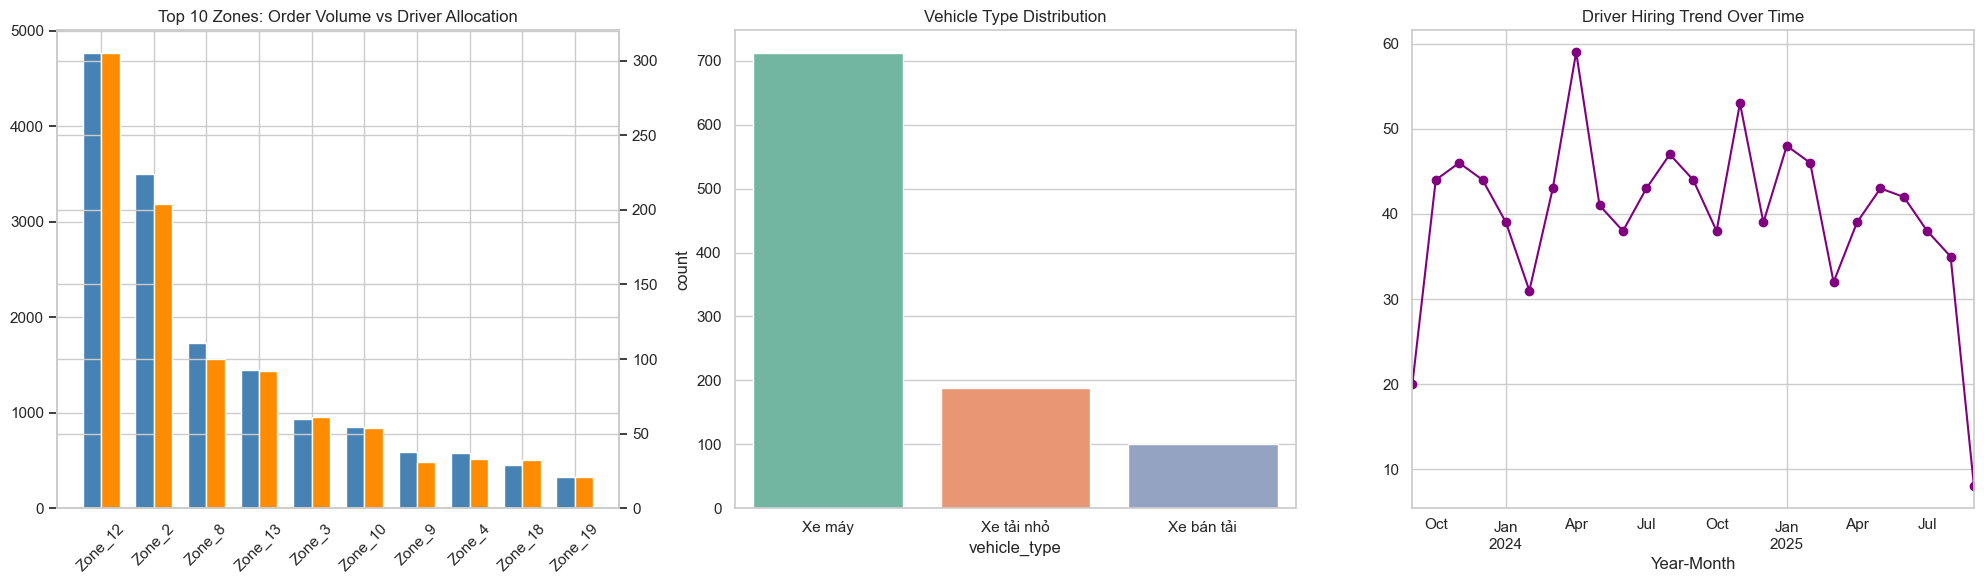

,driver_key,driver_id,driver_name,vehicle_type,home_zone_id,hire_date,driver_status,row_effective_date,row_end_date,is_current,hire_year_month
0,1,DRV-C4C49F,Patrick Sanchez,Xe máy,Zone_2,2025-01-17,Active,2025-01-17,9999-12-31,True,2025-01
1,2,DRV-200F23,Megan Mcclain,Xe máy,Zone_9,2023-12-26,Active,2023-12-26,9999-12-31,True,2023-12
2,3,DRV-2D4EB8,Amanda Davis,Xe máy,Zone_10,2023-11-15,Active,2023-11-15,9999-12-31,True,2023-11
3,4,DRV-2C4AF6,Alyssa Gonzalez,Xe máy,Zone_12,2024-03-07,Active,2024-03-07,9999-12-31,True,2024-03
4,5,DRV-98383F,Jennifer Cole,Xe máy,Zone_18,2025-01-25,On Leave,2025-01-25,9999-12-31,True,2025-01


In [3]:
import pandas as pd
import datetime
import numpy as np
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns
import uuid

# Cố định seed để dữ liệu sinh ra giống nhau ở mỗi lần chạy (dễ debug)
fake = Faker()
Faker.seed(42)
np.random.seed(42)

# ==========================================
# BƯỚC 1: Lấy phân phối (trọng số) từ Olist gốc
# ==========================================
# Ghi chú: Ở đây tôi giả lập một Dataframe tổng hợp mật độ đơn hàng từ Olist
# Trong thực tế, bạn query count(order_id) group by zone_id từ df_olist_orders
zones_mock = [f'Zone_{i}' for i in range(1, 21)]
# Giả lập phân phối Pareto (quy tắc 80/20) - một vài zone tập trung rất nhiều đơn
order_counts_mock = np.random.pareto(a=2, size=len(zones_mock)) * 1000 
df_zone_weights = pd.DataFrame({'zone_id': zones_mock, 'order_count': order_counts_mock})

# Tính toán xác suất (trọng số) dựa trên số lượng đơn hàng
df_zone_weights['weight'] = df_zone_weights['order_count'] / df_zone_weights['order_count'].sum()


# ==========================================
# BƯỚC 2: Khởi tạo dữ liệu dim_driver (SCD2)
# ==========================================
def generate_dim_driver(num_drivers, zone_weights_df):
    drivers = []
    
    # Định nghĩa tỷ lệ phương tiện giả định
    vehicle_types = ['Xe máy', 'Xe tải nhỏ', 'Xe bán tải']
    vehicle_weights = [0.70, 0.20, 0.10]
    
    # Định nghĩa trạng thái tài xế
    statuses = ['Active', 'Inactive', 'On Leave']
    status_weights = [0.85, 0.10, 0.05]

    for i in range(1, num_drivers + 1):
        # Ngày thuê: giới hạn trong khoảng thời gian dữ liệu Olist (2016-2018)
        hire_date = fake.date_between(start_date='-3y', end_date='-1y')
        
        driver = {
            'driver_key': i, # Surrogate key hệ thống tạo
            'driver_id': f'DRV-{uuid.uuid4().hex[:6].upper()}', # Synthetic ID
            'driver_name': fake.name(),
            'vehicle_type': np.random.choice(vehicle_types, p=vehicle_weights),
            # Gán home_zone_id theo trọng số mật độ đơn hàng thực tế của Olist
            'home_zone_id': np.random.choice(zone_weights_df['zone_id'], p=zone_weights_df['weight']),
            'hire_date': hire_date,
            'driver_status': np.random.choice(statuses, p=status_weights),
            # SCD2 control columns
            'row_effective_date': hire_date,
            'row_end_date': datetime.date(9999, 12, 31),
            'is_current': True
        }
        drivers.append(driver)

    return pd.DataFrame(drivers)

# Tạo thử 1000 tài xế
df_dim_driver = generate_dim_driver(1000, df_zone_weights)


# ==========================================
# BƯỚC 3: Trực quan hóa dữ liệu (Data Profiling)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Kiểm tra phân bổ Home Zone so với mật độ đơn hàng
# Nếu code chuẩn, các Zone có thanh màu xanh cao (nhiều đơn) sẽ có thanh màu cam cao (nhiều tài xế)
driver_zone_counts = df_dim_driver['home_zone_id'].value_counts().reset_index()
driver_zone_counts.columns = ['zone_id', 'driver_count']
comparison_df = pd.merge(df_zone_weights, driver_zone_counts, on='zone_id')
comparison_df = comparison_df.sort_values('order_count', ascending=False).head(10) # Xem top 10

x = np.arange(len(comparison_df['zone_id']))
width = 0.35
axes[0].bar(x - width/2, comparison_df['order_count'], width, label='Order Vol (Olist)', color='steelblue')
ax1_sec = axes[0].twinx()
ax1_sec.bar(x + width/2, comparison_df['driver_count'], width, label='Driver Vol (Mock)', color='darkorange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['zone_id'], rotation=45)
axes[0].set_title('Top 10 Zones: Order Volume vs Driver Allocation')

# Chart 2: Tỷ lệ loại phương tiện
sns.countplot(data=df_dim_driver, x='vehicle_type', ax=axes[1], palette='Set2')
axes[1].set_title('Vehicle Type Distribution')

# Chart 3: Xu hướng tuyển dụng tài xế theo thời gian
df_dim_driver['hire_year_month'] = pd.to_datetime(df_dim_driver['hire_date']).dt.to_period('M')
hire_trend = df_dim_driver.groupby('hire_year_month').size()
hire_trend.plot(kind='line', ax=axes[2], marker='o', color='purple')
axes[2].set_title('Driver Hiring Trend Over Time')
axes[2].set_xlabel('Year-Month')

plt.tight_layout()
plt.show()

# Hiển thị 5 dòng dữ liệu đầu tiên để check định dạng SCD2
display(df_dim_driver.head())